In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

%matplotlib inline
#from brokenaxes import brokenaxes


plt.rc('lines', linewidth=4)
plt.rc('legend',fontsize=16)
plt.rc('axes',labelsize=16)
plt.rc('xtick',labelsize=12)
plt.rc('xtick',direction='in')
plt.rc('ytick',labelsize=12)
plt.rc('axes',labelsize=16)
plt.rc('ytick',direction='in')
plt.rc('figure',figsize=(8,6))


In [2]:
dat = pd.read_csv('psf 400.txt',    names=('i','x','y')     )
dat852 = pd.read_csv('psf 852.txt',    header =14 , delimiter = '\t')


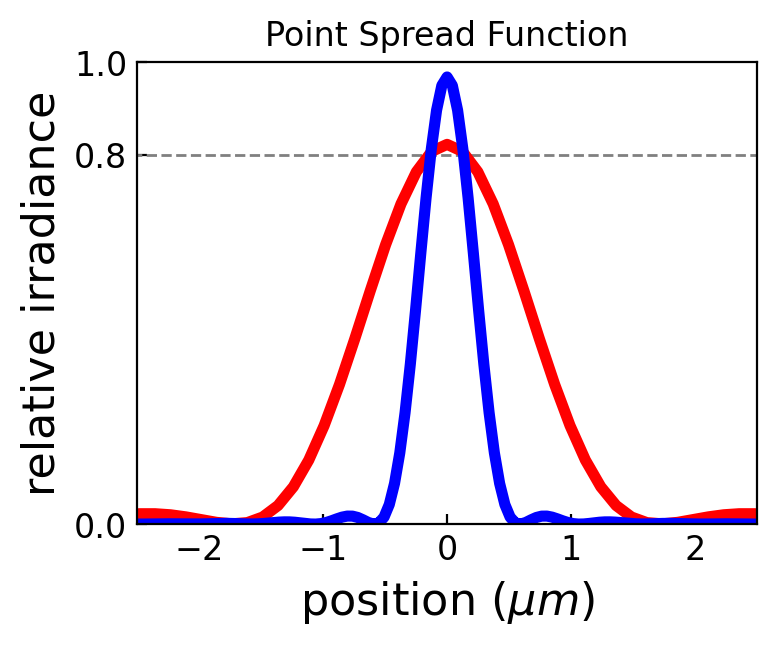

In [3]:
plt.figure(figsize =(4,3), dpi=200)
pmag = 125.9988
pmag852 = 7.57

plt.plot([-5,5],[.8,.8], color = 'grey', linestyle = '--', linewidth =1)
plt.plot(dat852['Position']/pmag852, dat852['Value'], color = 'r')

plt.plot(dat['x']/pmag, dat['y'], color = 'b')

#plt.plot([-.25,.25], [.5,.5])
plt.xlim(-2.5,2.5)

plt.ylim(0,1)
plt.yticks([0,.8,1])
plt.xlabel(r'position ($\mu m$)')
plt.ylabel(r'relative irradiance')
plt.title('Point Spread Function')
plt.savefig('psf.pdf')

images/0_init 2V/20250714164613097_0.bmp
(3120, 4200)


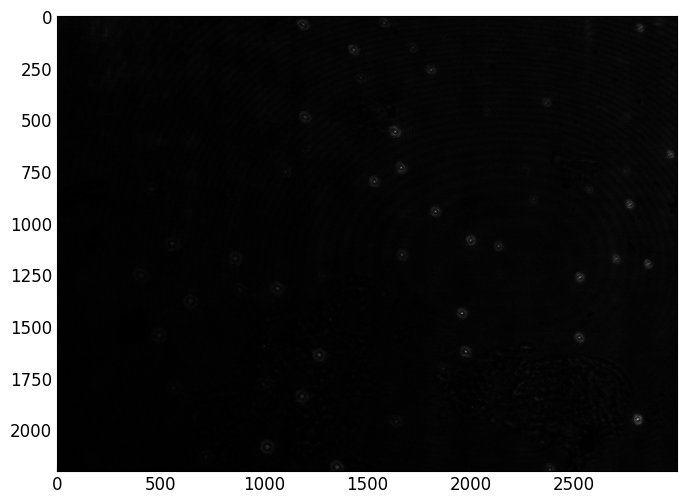

(2200, 3000)
(18, 3)


C:\Users\Tommy\AppData\Local\Temp\ipykernel_20440\3776008075.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


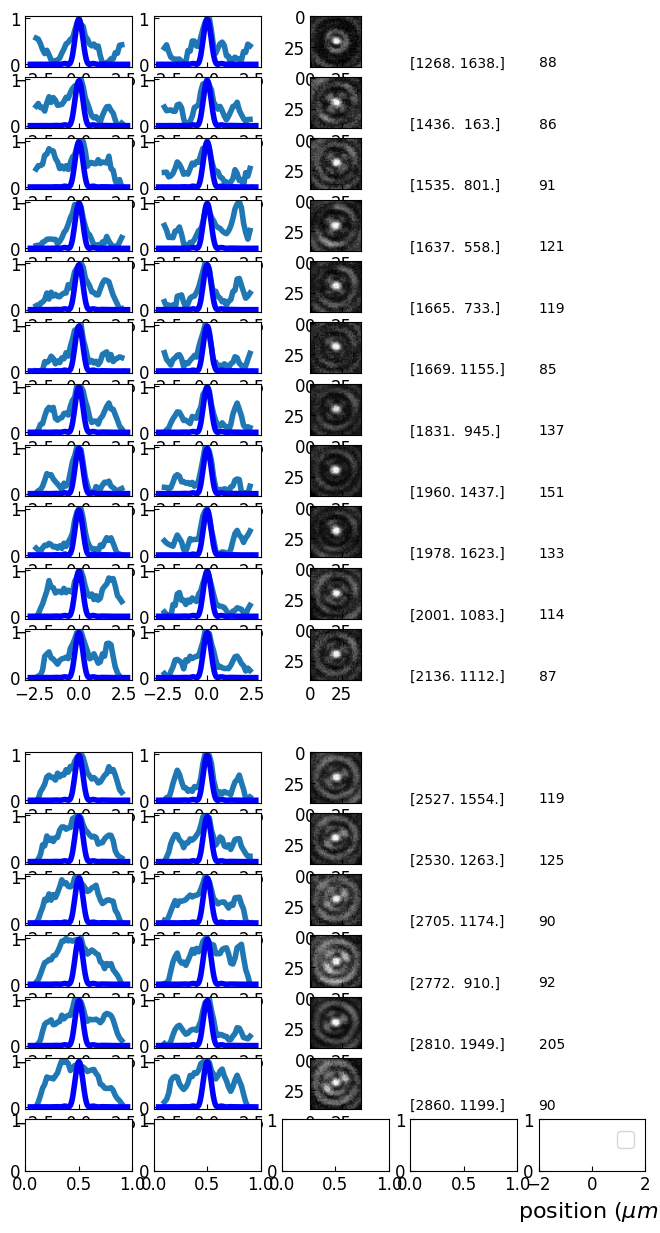

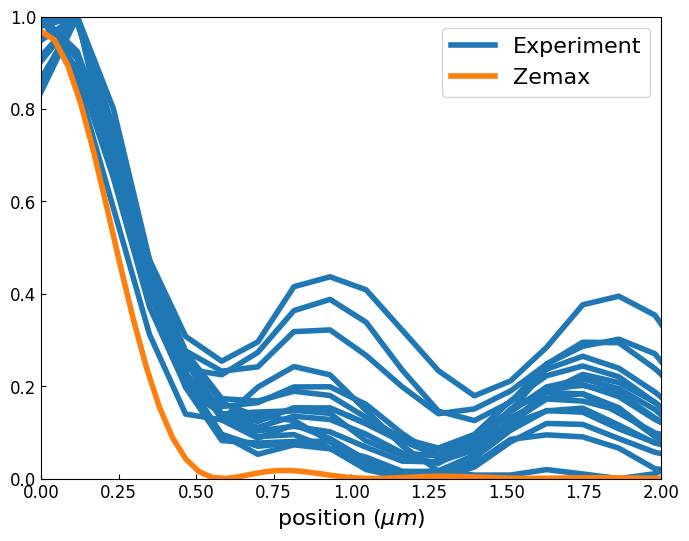

shape
(2200, 3000)


In [4]:
from PIL import Image
from operator import itemgetter


def radial_profile(data, center):
    y, x = np.indices((data.shape))
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    r = r.astype(int)

    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = tbin / nr
    return np.unique(r),radialprofile 

import os


directory = os.fsencode("images/0_init 2V/")
stack = []
all_x0s=[]
all_y0s=[]
for i,file in enumerate(sorted(os.listdir(directory))[10:11]):
    # plt.figure(dpi=200)
    filename = os.fsdecode(directory+file)
    im = np.array(Image.open(filename))
    print(filename)
    print(np.shape(im))
    im = im[400:2600,:3000] 
    plt.imshow(im, cmap= 'Greys_r')
    plt.show()

    print(im.shape)




    from skimage.feature import blob_dog, blob_log, blob_doh

    blobs = blob_dog(im, max_sigma=10, threshold=0.1)
    print(np.shape(blobs))
    

    blobs = sorted(blobs,key=itemgetter(1))
    # for b in blobs:
    #     plt.plot(np.mean(b[0]),np.mean(b[1]))
    
    l=0
    if np.shape(blobs)[0] > 0:
        fig, axs = plt.subplots(len(blobs)+1,5)
        margin = 20
        fig.set_figheight(15)
        

        x0s=[]
        y0s=[]
        for b in blobs:
            bim = im[int(b[0]-20):int(b[0]+21),int(b[1])-20:int(b[1]+21)]
                
            if bim.shape == (41,41):
            
            
                for a in [0,1]:
                    
                    X_ = np.linspace(0, bim.shape[0])
                    X_ = np.linspace(0, bim.shape[0]/8.5875, bim.shape[0])
                    X_ = X_ - np.mean(X_)
                    Y_ = np.sum(bim, axis = a)
                    Y_ = Y_ - np.min(Y_)
                    Y_ = Y_ / np.max(Y_)
                    axs[l,a].plot(X_,Y_)       
                    axs[l,a].plot(dat['x']/pmag, dat['y'], color = 'b', label = 'Zemax')
                axs[l,2].imshow(bim, cmap= 'Greys_r')
                axs[l,3].axis('off')
                axs[l,3].text(0,0,np.array((np.mean(b[1]), np.mean(b[0]))))
                axs[l,4].axis('off')
                axs[l,4].text(0,0,np.max(bim))
                x0s.append(int(np.mean(b[1])))
                y0s.append(int(np.mean(b[0])))
            else:
                axs[l,0].remove()
                axs[l,1].remove()
                axs[l,2].remove()
                axs[l,3].remove()
                axs[l,4].remove()
            plt.legend()
            plt.xlim(-2,2)
            plt.xlabel(r'position ($\mu m$)')
            l+=1
        plt.show()  
            
        all_x0s.append(x0s)
        all_y0s.append(y0s)
       

    for b in blobs:
            
            bim = im[int(b[0]-20):int(b[0]+21),int(b[1])-20:int(b[1]+21)]
            if bim.shape == (41,41):
             
                X_ = np.linspace(0, bim.shape[0])
                X_,Y_ = radial_profile(bim, (20,20))
                Y_ = Y_ - np.min(Y_)
                Y_ = Y_ / np.max(Y_)
                plt.plot(X_/8.5875,Y_, color = 'C0')
            else:
                continue
    plt.plot([],[], color = 'C0', label = 'Experiment')
    plt.plot(dat['x']/pmag, dat['y'], color = 'C1', label = 'Zemax')
    plt.legend()
    plt.xlim(0,2)
    plt.ylim(0,1)
    plt.xlabel(r'position ($\mu m$)')
    plt.show()
    print('shape')
    print(np.shape(im))



[1268, 1436, 1535, 1637, 1665, 1669, 1831, 1960, 1978, 2001, 2136, 2527, 2530, 2705, 2772, 2810, 2860] [1638, 163, 801, 558, 733, 1155, 945, 1437, 1623, 1083, 1112, 1554, 1263, 1174, 910, 1949, 1199]
images/0_init 2V/20250714164547239_0.bmp
2138


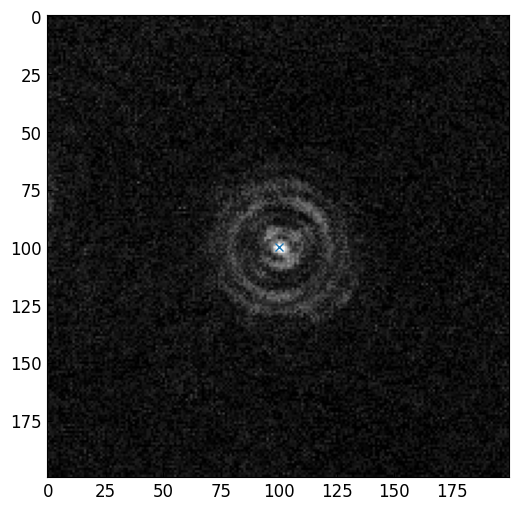

images/0_init 2V/20250714164556479_0.bmp
2138


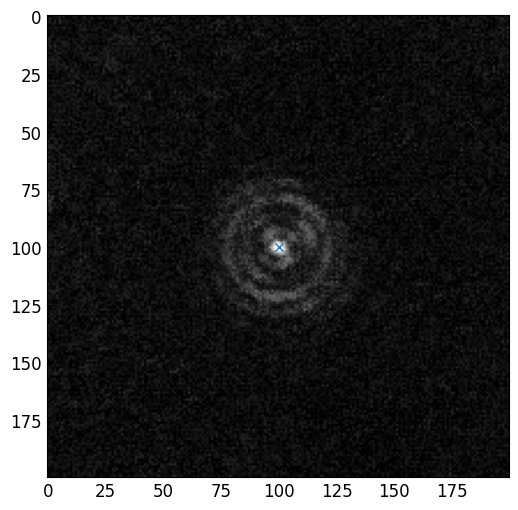

images/0_init 2V/20250714164602999_0.bmp
2138


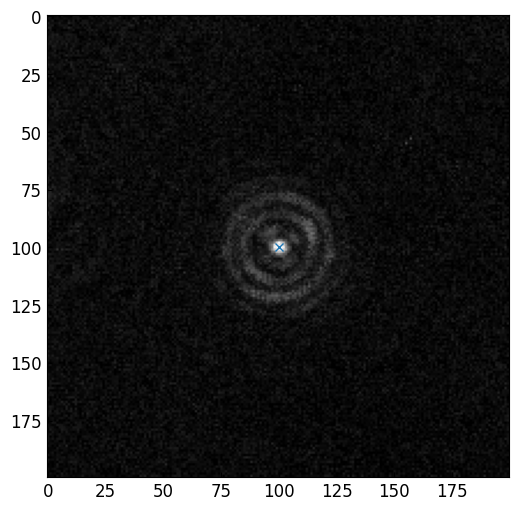

images/0_init 2V/20250714164613097_0.bmp
2138


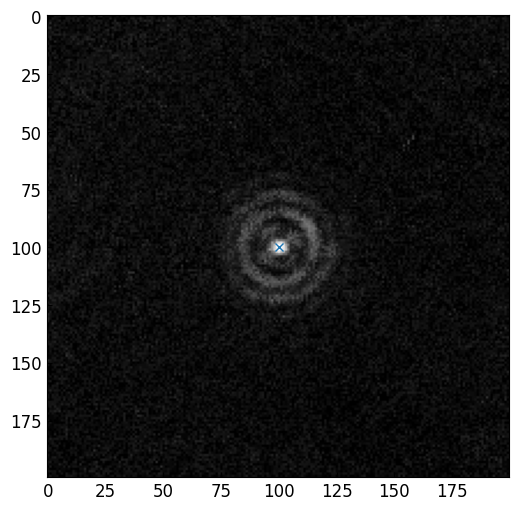

images/0_init 2V/20250714164623051_0.bmp
2138


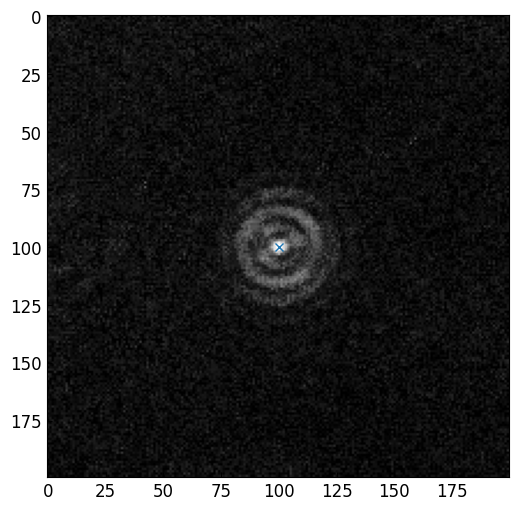

images/0_init 2V/20250714164627133_0.bmp
2138


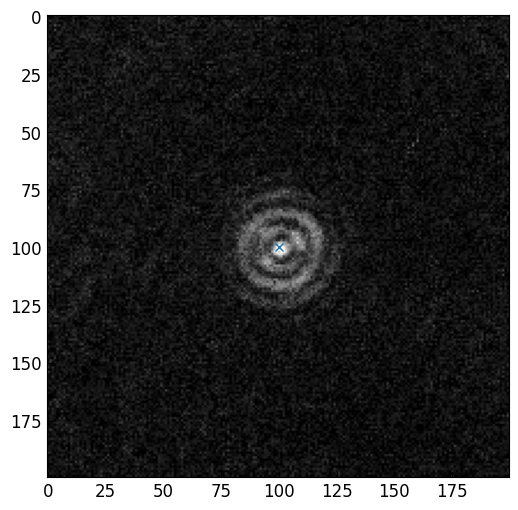

images/0_init 2V/20250714164642881_0.bmp
2138


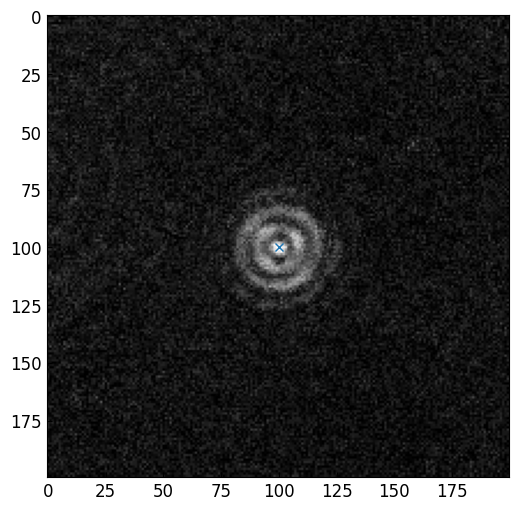

images/0_init 2V/20250714164649549_0.bmp
2138


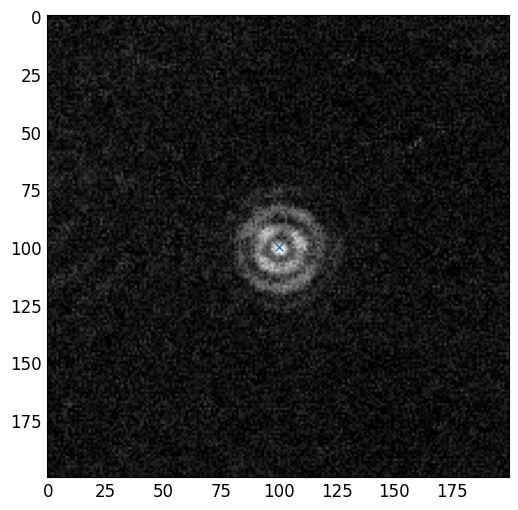

images/0_init 2V/20250714164657071_0.bmp
2138


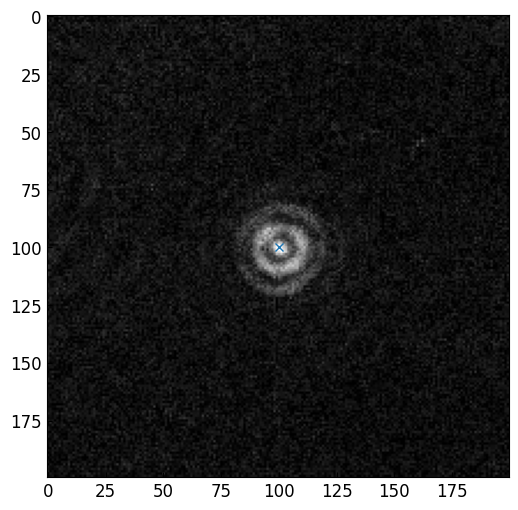

images/0_init 2V/20250714164704444_0.bmp
2138


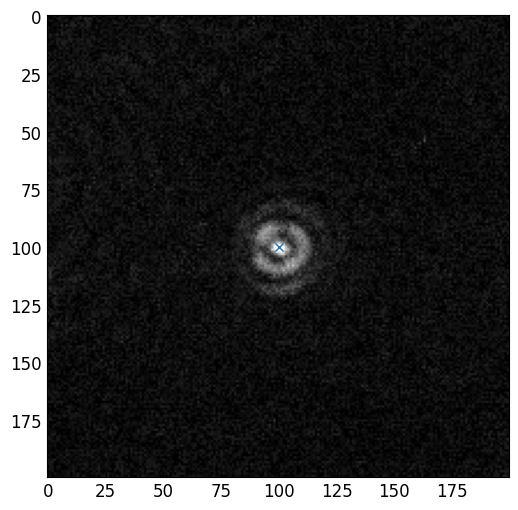

images/0_init 2V/20250714164712539_0.bmp
2138


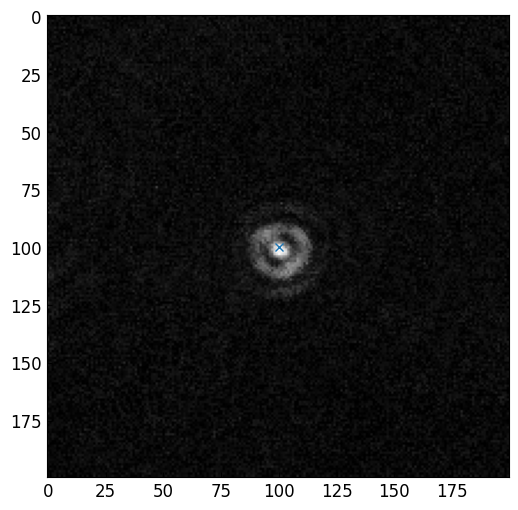

images/0_init 2V/20250714164721635_0.bmp
2138


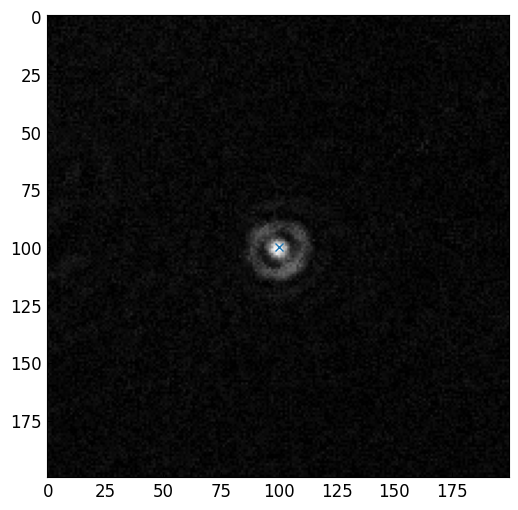

images/0_init 2V/20250714164730591_0.bmp
2138


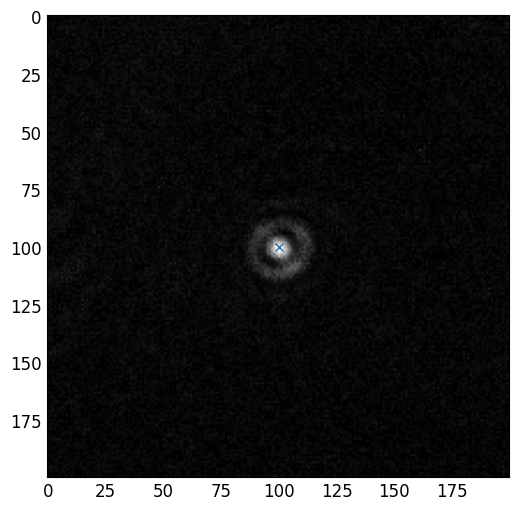

3.5802649295440743


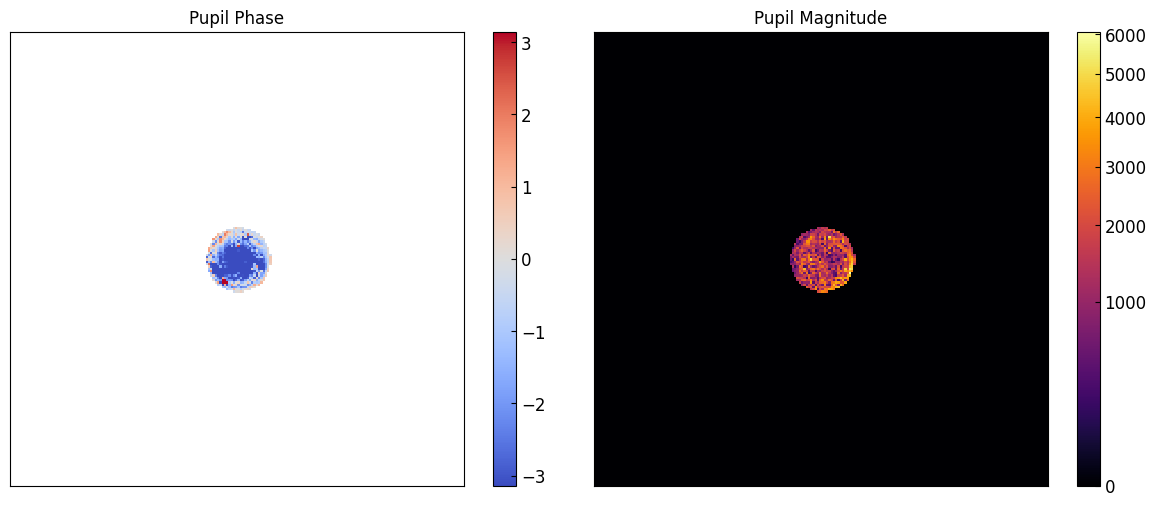

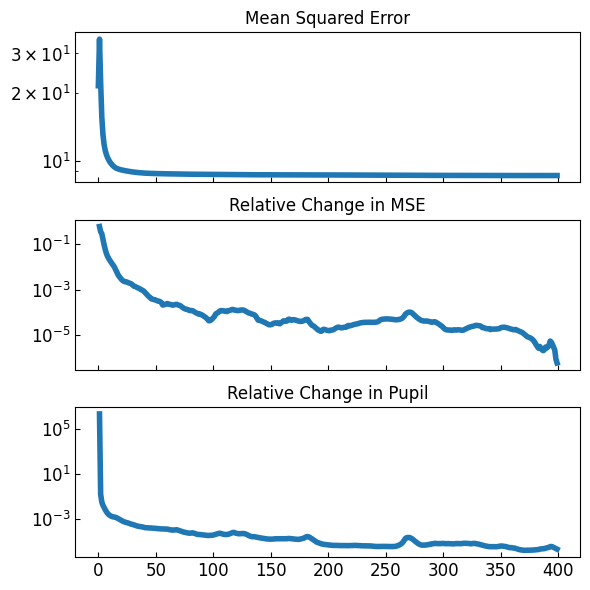

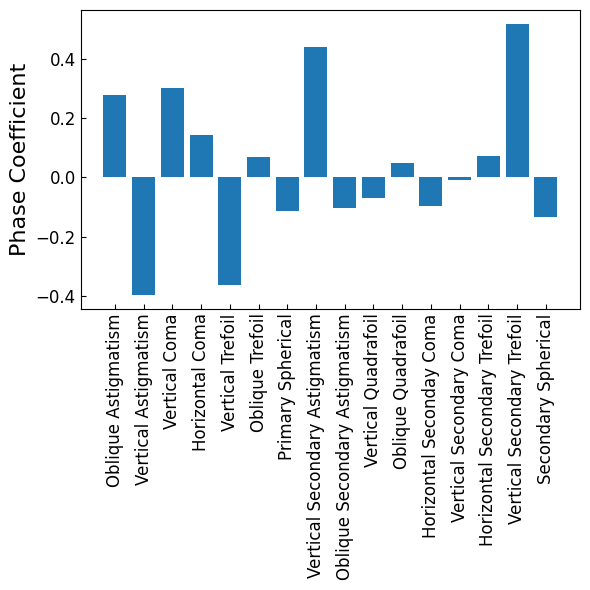

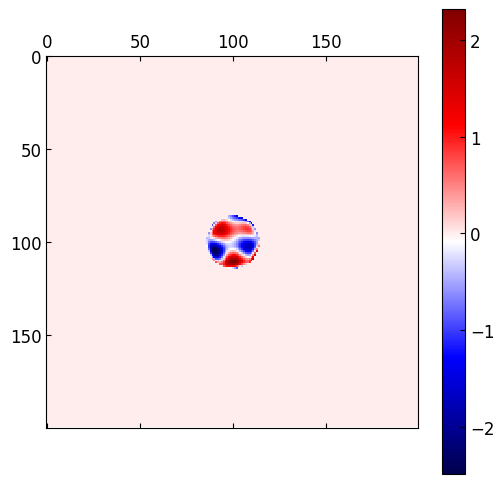

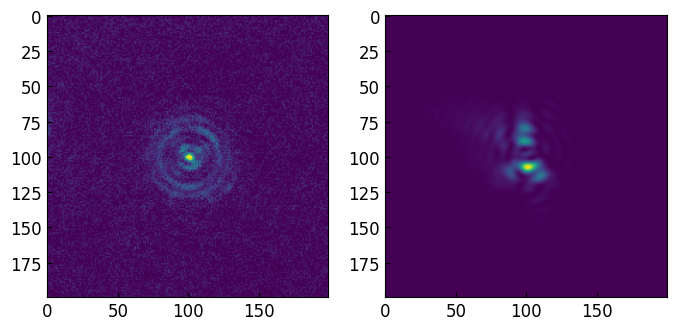

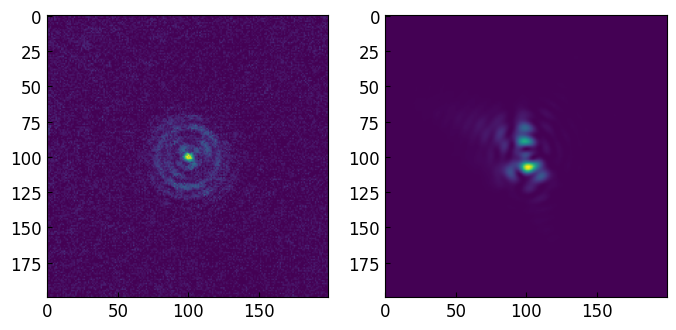

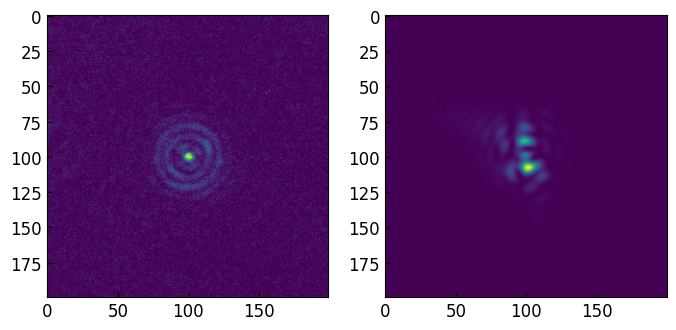

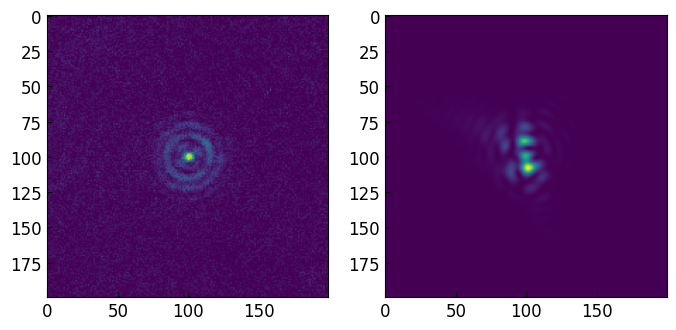

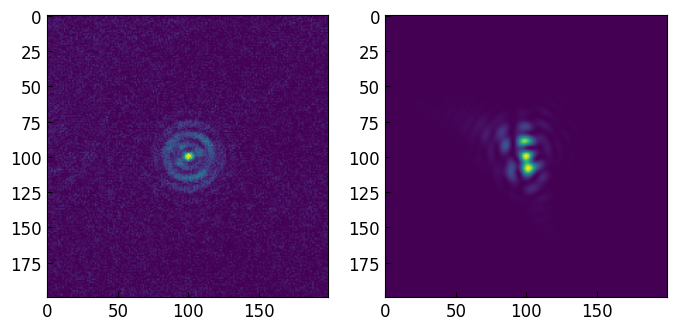

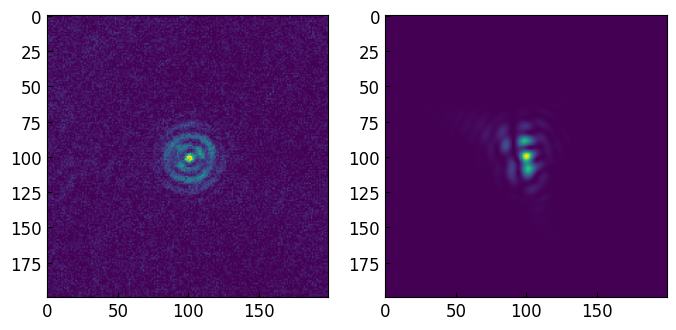

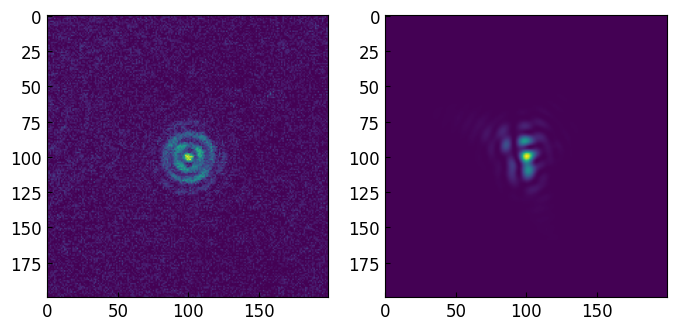

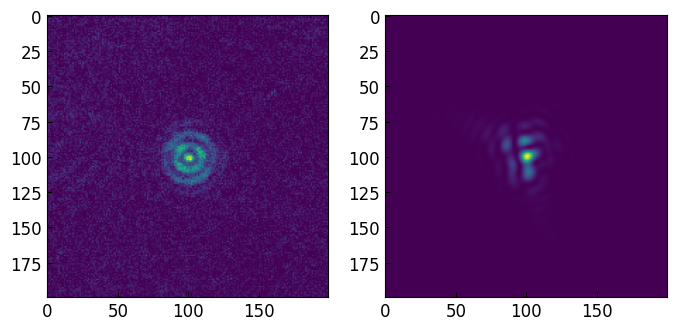

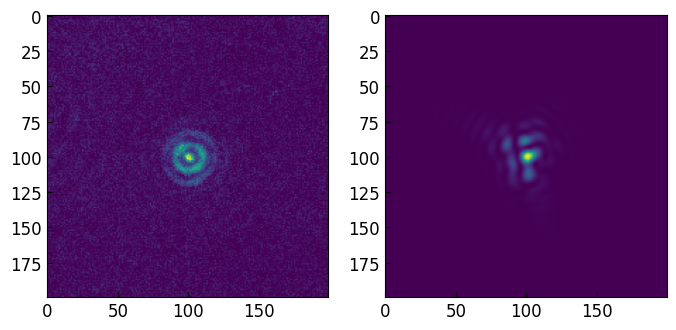

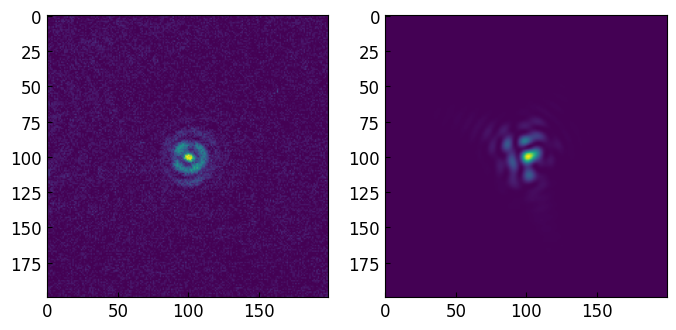

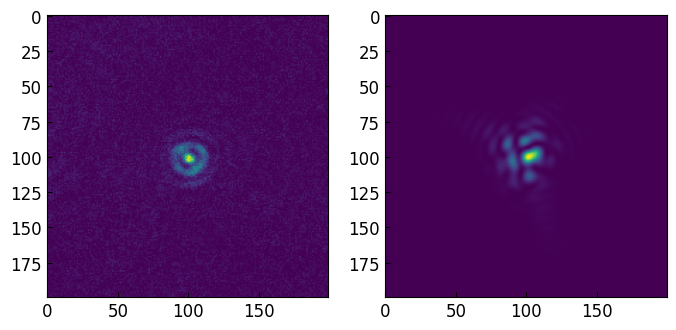

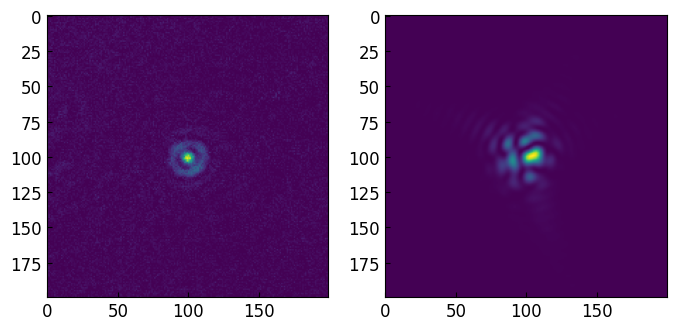

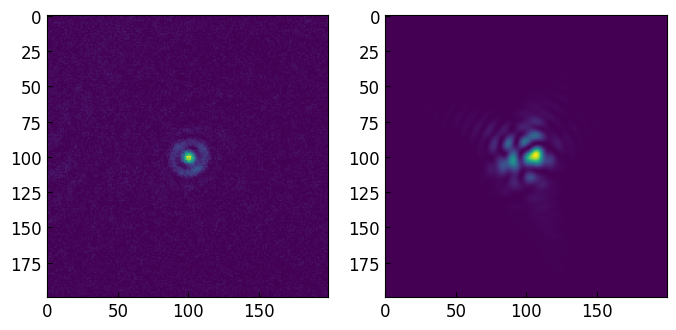

In [9]:
blob = 10
l=100

x0 = int(x0s[blob])+2
y0 = int(y0s[blob])

print(x0s,y0s)

stack = []

for i,file in enumerate(sorted(os.listdir(directory))[7:-4]):


    filename = os.fsdecode(directory+file)

    print(filename)

    im = np.array(Image.open(filename))
    
    im = im[400:2600,:3000] 

    xshift = int(-.8*i)

    yshift = int(-.2*i)
    print(x0)

    p = np.array(im)[y0-l+yshift:y0+l+yshift,x0-l+xshift:x0+l+xshift]

    plt.plot([l,], [l,],'x')

    stack.append(p)

    plt.imshow(p, cmap = 'Greys_r')

    plt.show()

stack = np.array(stack[:])

 

test_data =stack

 

#from pyotf import HanserPSF

from pyotf.phaseretrieval import *

from pyotf.utils import *

 

params = dict(

    size=test_data.shape[-1],

    zsize=test_data.shape[0],

    na=0.25,

    res=114  ,

    zres=100000/150*2,

    wl=399,

    ni=1.0,

    vec_corr="none",

    condition="none",

)
 

params["size"] = 512

junk = prep_data_for_PR(test_data, None, 1.05)


result = retrieve_phase(junk, params, 400, pupil_tol=np.nan, mse_tol=np.nan, phase_only=False)

result.plot()
result.plot_convergence()

zd_result = result.fit_to_zernikes(20)

zd_result.plot_named_coefs()
plt.matshow(zd_result.phase(slice(4, None, None)), cmap="seismic")
plt.colorbar()

print(result.rms_error)


plt.figure()

psf = result.generate_zd_psf()
for im,sim in zip(junk,psf):

    plt.subplot(1,2,1)

    plt.imshow(im)   

    plt.subplot(1,2,2)

    plt.imshow(sim)

   

    

    plt.show()

In [35]:
l=100
 

params["size"] = 512

coefs = []

for b in range(len(blobs)+1):

    stack = []

    x0 = int(x0s[b])+14

    y0 = int(y0s[b])-3

    for i,file in enumerate(sorted(os.listdir(directory))[7:-4]):


        filename = os.fsdecode(directory+file)

        im = np.array(Image.open(filename))
        
        im = im[400:2600,:3000] 

        xshift = int(-3.4*i)

        yshift = int(0.6*i)

        p = np.array(im)[y0-l+yshift:y0+l+yshift,x0-l+xshift:x0+l+xshift]
        print(np.shape(p))
        if np.shape(p)==[l,l]:
            stack.append(p)
    
    stack = np.array(stack)

    test_data =stack

    params = dict(

    size=test_data.shape[-1],

    zsize=test_data.shape[0],

    na=0.3,

    res=114  ,

    zres=100000/150*5,

    wl=399,

    ni=1.0,

    vec_corr="none",

    condition="none",

    )
    
    junk = prep_data_for_PR(test_data, None, 1.05)


    result = retrieve_phase(junk, params, 400, pupil_tol=np.nan, mse_tol=np.nan, phase_only=False)

    zd_result = result.fit_to_zernikes(20)
    coefs.append(zd_result.pcoefs)

plt.figure()
for i in range(len(coefs)):
    for j in range(len(coefs[0])):
        plt.plot(x0s[i],coefs[:,j])
plt.show()



(162, 200)
(162, 200)
(161, 200)
(161, 200)
(160, 200)
(159, 200)
(159, 200)
(158, 200)


ValueError: not enough values to unpack (expected 3, got 1)